# Delay-and-Sum Beamforming

Delay-and-sum (DAS), also called conventional beamforming, steers the array by phase-aligning a look direction and summing the sensors. Following PySDR notation, the conventional weights are the steering vector for the look angle:

$$
w = s(\theta)
$$

The beamformer output is:

$$
X_{weighted}(\theta) = w^H X
$$

For DOA estimation, the look direction is swept over a range of angles and the output power is evaluated at each angle:

$$
P_{DAS}(\theta) = var(X_{weighted}(\theta))
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True


In [2]:
# Signal `x`
sample_rate = 1e6
N = 10000
t = np.arange(N) / sample_rate
f = 0.01e6

# signal as row vector
x = np.exp(2j * np.pi * f * t).reshape(1, -1)

print(x.shape)    # should be (1, N)


(1, 10000)


In [3]:
# Array setup
d = 0.5   # distance between microphones in wavelengths
Nr = 8    # 8 elements

# Steering vector `s` in radians
theta = 20 / 180 * np.pi

s = np.exp(2j * np.pi * d * np.arange(Nr) * np.sin(theta)).reshape(-1, 1)

print(s.shape)   # should be (Nr, 1)


(8, 1)


In [4]:
# Matrix `X`
X = s @ x

# Optional noise
n = np.random.randn(Nr, N) + 1j * np.random.randn(Nr, N)
X = X + 0.05 * n  # Nr x N

print(X.shape)    # should be (Nr, N)


(8, 10000)


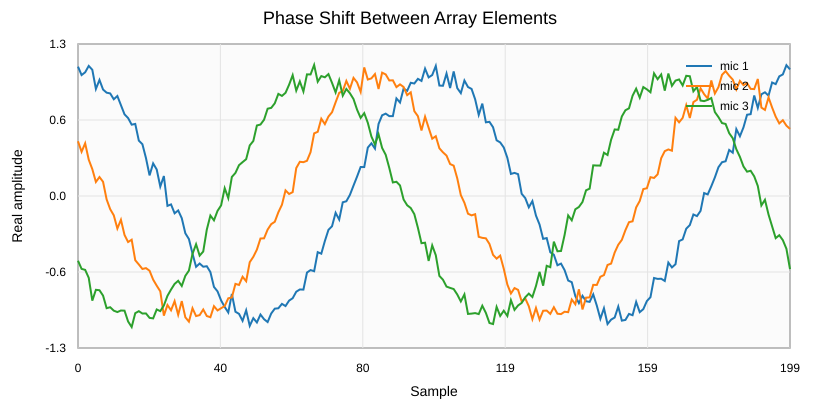

In [5]:
# Phase shift between elements of array
plt.plot(np.asarray(X[0, :]).squeeze().real[0:200], label="mic 1")
plt.plot(np.asarray(X[1, :]).squeeze().real[0:200], label="mic 2")
plt.plot(np.asarray(X[2, :]).squeeze().real[0:200], label="mic 3")
plt.xlabel("Sample")
plt.ylabel("Real amplitude")
plt.title("Phase Shift Between Array Elements")
plt.legend()
plt.show()


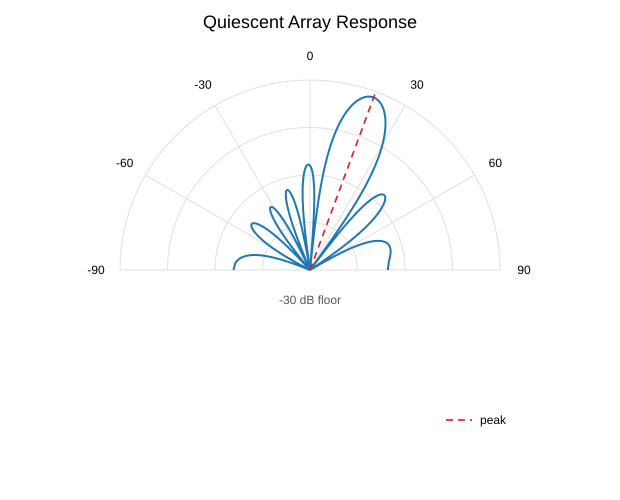

In [ ]:
# Quiescent response
N_fft = 512
theta_degrees = 20  # no SOI here; this is just the direction we want to point at
theta = theta_degrees / 180 * np.pi

w = np.exp(2j * np.pi * d * np.arange(Nr) * np.sin(theta))
w_padded = np.concatenate((w, np.zeros(N_fft - Nr)))
w_fft_dB = 10 * np.log10(np.abs(np.fft.fftshift(np.fft.fft(w_padded))) ** 2)
w_fft_dB -= np.max(w_fft_dB)

# Map the FFT bins to angles in radians
theta_bins = np.arcsin(np.linspace(-1, 1, N_fft))

theta_max = theta_bins[np.argmax(w_fft_dB)]

fig, ax = plt.subplots(figsize=(6, 4),subplot_kw={"projection": "polar"})
ax.plot(theta_bins, w_fft_dB)  # polar plots use radians
ax.plot([theta_max], [np.max(w_fft_dB)], "ro")
ax.text(theta_max - 0.1, np.max(w_fft_dB) - 4, np.round(theta_max * 180 / np.pi))
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_rlabel_position(55)
ax.set_thetamin(-90)
ax.set_thetamax(90)
ax.set_ylim([-30, 1])
ax.set_title("Quiescent Array Response")
plt.show()


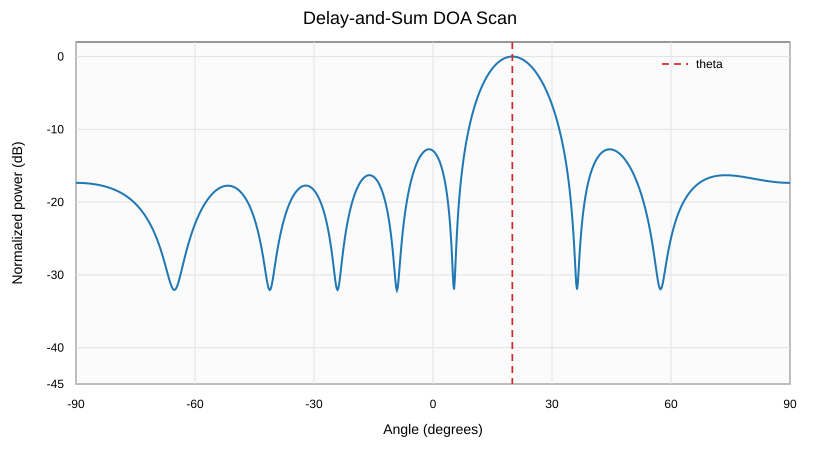

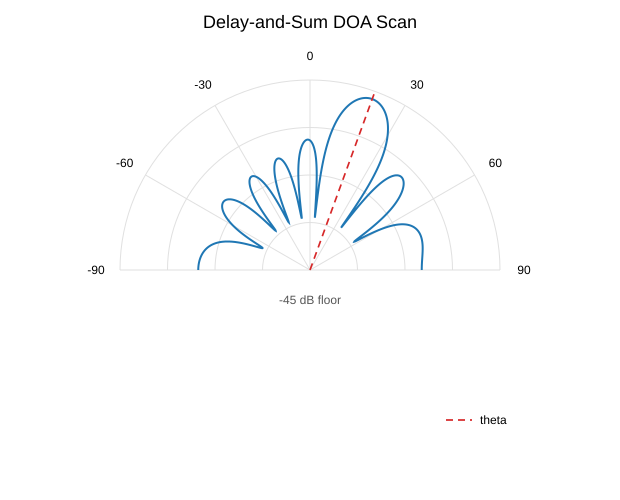

In [ ]:
# Delay-and-sum DOA scan
theta_scan = np.linspace(-1 * np.pi / 2, np.pi / 2, 1000)
theta_scan_deg = theta_scan * 180 / np.pi

s = np.exp(2j * np.pi * d * np.arange(Nr).reshape(-1, 1) * np.sin(theta_scan))
X_weighted = s.conj().T @ X
results = np.var(X_weighted, axis=1)
results_db = 10 * np.log10(results / np.max(results))

# Cartesian plot
plt.plot(theta_scan_deg, results_db)
plt.axvline(theta * 180 / np.pi, color="tab:red", linestyle="--", label="theta")
plt.xlabel("Angle (degrees)")
plt.ylabel("Normalized power (dB)")
plt.title("Delay-and-Sum DOA Scan")
plt.ylim(-45, 2)
plt.legend()
plt.show()

# Polar plot
radial_floor = -45
fig, ax = plt.subplots(figsize=(6, 4),subplot_kw={"projection": "polar"})
ax.plot(theta_scan, results_db)
ax.plot([theta, theta], [radial_floor, 0], color="tab:red", linestyle="--", label="theta")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_thetamin(-90)
ax.set_thetamax(90)
ax.set_ylim(radial_floor, 2)
ax.set_title("Delay-and-Sum DOA Scan")
ax.legend(loc="upper right")
plt.show()
